# 01 - Data Collection (World Bank WDI) for ALI (2022)

This notebook downloads World Bank indicator data for the Affordable Liveability Index (ALI) for year = 2022, creates an initial country-level dataset and outputs:

- `data/raw/wdi_2022_initial.csv`
- `outputs/figures/missingness_by_indicator.png`

Next notebook will handle cleaning rules and imputation.

In [12]:
import pandas as pd
import numpy as np
import requests
from functools import reduce
import matplotlib.pyplot as plt

In [13]:
YEAR = 2022

# Initial indicator set
# World Bank indicator codes: https://data.worldbank.org/indicator
INDICATORS = {
    # Economic Opportunity (EO)
    "NY.GDP.PCAP.PP.KD": "gdp_per_capita_ppp_const",   # GDP per capita, PPP (constant international $)
    "SL.UEM.TOTL.ZS": "unemployment_rate",            # Unemployment, total (% of labor force)
    "SL.TLF.CACT.ZS": "labor_force_participation",    # Labor force participation rate (% ages 15+)

    # Quality of Life & Environment (QLE)
    "SP.DYN.LE00.IN": "life_expectancy",              # Life expectancy at birth, total (years)
    "EN.ATM.PM25.MC.M3": "pm25_exposure",             # PM2.5 air pollution, mean annual exposure (micrograms per cubic meter)
    "VC.IHR.PSRC.P5": "homicide_rate",                # Intentional homicides (per 100,000 people)

    # Cost pressure proxy (CP)
    "PA.NUS.PPP": "ppp_conversion_factor"             # PPP conversion factor (LCU per international $)
}

In [14]:
def fetch_world_bank_indicator(ind_code: str, year: int) -> pd.DataFrame:
    """
    Fetch one World Bank indicator for all countries for given year.
    Returns a normalized DataFrame of API records.
    """
    url = (
        "https://api.worldbank.org/v2/country/all/indicator/"
        f"{ind_code}?format=json&per_page=20000&date={year}"
    )
    r = requests.get(url, timeout=60)
    r.raise_for_status()
    payload = r.json()

    # Expected: [metadata, records]
    if not isinstance(payload, list) or len(payload) < 2:
        raise ValueError(f"Unexpected response format for {ind_code}: {type(payload)}")

    records = payload[1] or []
    df = pd.json_normalize(records)
    return df

In [15]:
frames = []
failed = []

for code, short in INDICATORS.items():
    try:
        df = fetch_world_bank_indicator(code, YEAR)

        if df.empty:
            failed.append((code, "empty dataframe"))
            continue

        required_cols = ["country.value", "countryiso3code", "date", "value"]
        missing_cols = [c for c in required_cols if c not in df.columns]
        if missing_cols:
            failed.append((code, f"missing cols: {missing_cols}"))
            continue

        df = df[required_cols].copy()
        df.rename(
            columns={
                "country.value": "country",
                "countryiso3code": "iso3",
                "date": "year",
                "value": short,
            },
            inplace=True,
        )

        frames.append(df)
        print(f"OK: {code} -> {short}, rows={len(df)}")

    except Exception as e:
        failed.append((code, str(e)))
        print(f"FAIL: {code} ({short}) -> {e}")

print("\nSummary")
print("Indicators requested:", len(INDICATORS))
print("Indicators pulled:", len(frames))
print("Failed indicators:", failed)

OK: NY.GDP.PCAP.PP.KD -> gdp_per_capita_ppp_const, rows=266
OK: SL.UEM.TOTL.ZS -> unemployment_rate, rows=266
OK: SL.TLF.CACT.ZS -> labor_force_participation, rows=266
OK: SP.DYN.LE00.IN -> life_expectancy, rows=266
OK: EN.ATM.PM25.MC.M3 -> pm25_exposure, rows=266
OK: VC.IHR.PSRC.P5 -> homicide_rate, rows=266
OK: PA.NUS.PPP -> ppp_conversion_factor, rows=266

Summary
Indicators requested: 7
Indicators pulled: 7
Failed indicators: []


In [16]:
if len(frames) == 0:
    raise RuntimeError("No indicators were downloaded. Check your internet connection or indicator codes.")

data = reduce(
    lambda left, right: pd.merge(left, right, on=["iso3", "year", "country"], how="outer"),
    frames
)

data["year"] = data["year"].astype(int)
data.head(), data.shape

(               country iso3  year  gdp_per_capita_ppp_const  \
 0          High income       2022              56904.445664   
 1           Low income       2022               2312.384431   
 2  Lower middle income       2022               8238.695382   
 3       Not classified       2022                       NaN   
 4  Upper middle income       2022              20094.837995   
 
    unemployment_rate  labor_force_participation  life_expectancy  \
 0           4.509671                  61.020824        79.426777   
 1           5.672232                  61.517158        63.458341   
 2           4.773004                  57.710270        69.301095   
 3                NaN                        NaN              NaN   
 4           6.013911                  63.213737        76.008959   
 
   pm25_exposure  homicide_rate  ppp_conversion_factor  
 0          None            3.1                    NaN  
 1          None           10.7                    NaN  
 2          None           

In [17]:
indicator_cols = list(INDICATORS.values())

for c in indicator_cols:
    if c in data.columns:
        data[c] = pd.to_numeric(data[c], errors="coerce")

data[indicator_cols].isna().mean().sort_values(ascending=False)

pm25_exposure                1.000000
homicide_rate                0.533835
ppp_conversion_factor        0.251880
unemployment_rate            0.120301
labor_force_participation    0.120301
gdp_per_capita_ppp_const     0.071429
life_expectancy              0.003759
dtype: float64

In [18]:
# Drop entries without ISO3 (usually aggregates)
data = data.dropna(subset=["iso3"]).copy()

# Drop common World Bank aggregate regions/income groups
AGGREGATE_ISO3 = set([
    "WLD","HIC","MIC","LIC",
    "EAP","ECA","ECS","EMU","EUU",
    "LAC","LCN","MNA","MEA","NAC",
    "OED","SAS","SSA"
])

data = data[~data["iso3"].isin(AGGREGATE_ISO3)].copy()

# Keep only ISO3 codes that look valid
data = data[data["iso3"].str.fullmatch(r"[A-Z]{3}", na=False)].copy()

data.shape

(246, 10)

In [19]:
missing = data.isna().mean().sort_values(ascending=False)
missing

pm25_exposure                1.000000
homicide_rate                0.536585
ppp_conversion_factor        0.191057
labor_force_participation    0.126016
unemployment_rate            0.126016
gdp_per_capita_ppp_const     0.073171
iso3                         0.000000
country                      0.000000
year                         0.000000
life_expectancy              0.000000
dtype: float64

'../outputs/figures/missingness_by_indicator.png'

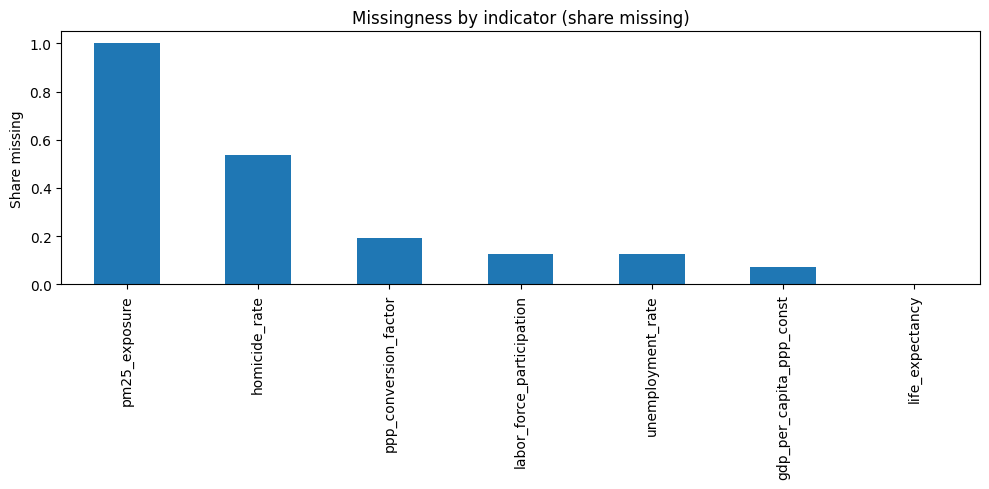

In [20]:
missing_ind = missing.drop(["country", "iso3", "year"], errors="ignore").sort_values(ascending=False)

plt.figure(figsize=(10, 5))
missing_ind.plot(kind="bar")
plt.title("Missingness by indicator (share missing)")
plt.ylabel("Share missing")
plt.tight_layout()

fig_path = "../outputs/figures/missingness_by_indicator.png"
plt.savefig(fig_path, dpi=200)
fig_path

In [21]:
out_path = "../data/raw/wdi_2022_initial.csv"
data.to_csv(out_path, index=False)
out_path

'../data/raw/wdi_2022_initial.csv'

In [22]:
data.sample(5, random_state=42)

,country,iso3,year,gdp_per_capita_ppp_const,unemployment_rate,labor_force_participation,life_expectancy,pm25_exposure,homicide_rate,ppp_conversion_factor
38,Botswana,BWA,2022,18647.373459,23.615000,64.621000,68.749000,NaN,NaN,5.156783
11,Andorra,AND,2022,63913.383508,NaN,NaN,84.016000,NaN,NaN,0.588248
198,Pacific island small states,PSS,2022,6653.231263,3.606816,64.451538,69.100435,NaN,NaN,NaN
96,Greenland,GRL,2022,70681.225390,NaN,NaN,71.230244,NaN,NaN,5.199148
170,Malaysia,MYS,2022,32129.221782,3.930000,66.223000,75.444000,NaN,0.691732,1.502991
